# Refinery Optimization Results Visualization

This notebook provides comprehensive visualization of the CPLEX refinery scheduling optimization results, including:

1. **Daily Crude Processing**: Stacked bar charts showing crude grades processed each day
2. **Vessel Delivery Schedule**: Timeline of crude deliveries by vessels
3. **Vessel Movement Tracking**: Visualization of vessel travel patterns and logistics
4. **Inventory Management**: Tank levels and crude storage over time

Data source: CPLEX optimization results from `crude_blending_*.csv` and `vessel_routing_*.csv` files.

In [7]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print("Available visualization tools: Matplotlib, Seaborn, Plotly")

Libraries imported successfully!
Available visualization tools: Matplotlib, Seaborn, Plotly


In [8]:
# Load Optimization Results Data
import os
import glob

# Find the latest optimization results
results_path = "./results/"
if not os.path.exists(results_path):
    print("Results directory not found. Please run the optimization first.")
else:
    # Get the latest files
    blending_files = glob.glob(f"{results_path}crude_blending_*.csv")
    vessel_files = glob.glob(f"{results_path}vessel_routing_*.csv")
    
    if blending_files and vessel_files:
        # Use the most recent files
        latest_blending = max(blending_files, key=os.path.getctime)
        latest_vessel = max(vessel_files, key=os.path.getctime)
        
        print(f"Loading data from:")
        print(f"- Blending: {os.path.basename(latest_blending)}")
        print(f"- Vessel: {os.path.basename(latest_vessel)}")
        
        # Load the data
        df_blending = pd.read_csv(latest_blending)
        df_vessel = pd.read_csv(latest_vessel)
        
        # Convert date columns
        df_blending['Date'] = pd.to_datetime(df_blending['Date'])
        df_vessel['Date'] = pd.to_datetime(df_vessel['Date'])
        
        print(f"\nData loaded successfully!")
        print(f"- Blending data: {len(df_blending)} records from {df_blending['Date'].min().date()} to {df_blending['Date'].max().date()}")
        print(f"- Vessel data: {len(df_vessel)} records, {df_vessel['Vessel ID'].nunique()} vessels")
    else:
        print("No optimization result files found. Please run the optimization first.")
        print("Expected files: crude_blending_*.csv and vessel_routing_*.csv")

Loading data from:
- Blending: crude_blending_throughput_7vessels_40days_40demurrage_20250925_103914.csv
- Vessel: vessel_routing_throughput_7vessels_40days_40demurrage_20250925_103914.csv

Data loaded successfully!
Data loaded successfully!
- Blending data: 43 records from 2025-10-01 to 2025-11-09
- Vessel data: 52 records, 7 vessels

- Blending data: 43 records from 2025-10-01 to 2025-11-09
- Vessel data: 52 records, 7 vessels


In [9]:
# Data Preprocessing for Visualization
if 'df_blending' in locals():
    # Extract crude blending data
    crude_columns = [col for col in df_blending.columns if 'Crude' in col and 'Blended' in col]
    print(f"Found crude types: {[col.replace('Crude ', '').replace(' Blended (kb)', '') for col in crude_columns]}")
    
    # Create daily crude processing summary
    daily_crude_processing = []
    
    for _, row in df_blending.iterrows():
        date = row['Date']
        slot = row['Slot']
        product = row['Final Product']
        quantity = row['Quantity Produced (kb)']
        
        # Extract crude usage for this production slot
        for crude_col in crude_columns:
            crude_name = crude_col.replace('Crude ', '').replace(' Blended (kb)', '')
            crude_quantity = row[crude_col]
            
            if crude_quantity > 0:  # Only include crudes that were actually used
                daily_crude_processing.append({
                    'Date': date,
                    'Slot': slot,
                    'Product': product,
                    'Crude_Type': crude_name,
                    'Crude_Quantity_kb': crude_quantity,
                    'Total_Production_kb': quantity
                })
    
    df_crude_daily = pd.DataFrame(daily_crude_processing)
    
    if not df_crude_daily.empty:
        print(f"\nProcessed {len(df_crude_daily)} crude usage records")
        print(f"Crude types used: {sorted(df_crude_daily['Crude_Type'].unique())}")
        print(f"Products produced: {sorted(df_crude_daily['Product'].unique())}")
    else:
        print("No crude processing data found")
else:
    print("Please run the data loading cell first")

Found crude types: ['Tapis', 'Minas', 'Tapis3rd', 'Sepat', 'KimC', 'Kimanis', 'Bintulu']

Processed 60 crude usage records
Crude types used: ['Bintulu', 'KimC', 'Kimanis', 'Minas', 'Sepat', 'Tapis', 'Tapis3rd']
Products produced: ['F1', 'F2', 'F3', 'F4', 'F5', 'F7', 'F8', 'F9']


## 1. Daily Crude Processing Visualization

This section shows the day-by-day processing of different crude oil grades in a stacked bar chart format.

<Figure size 1500x800 with 0 Axes>

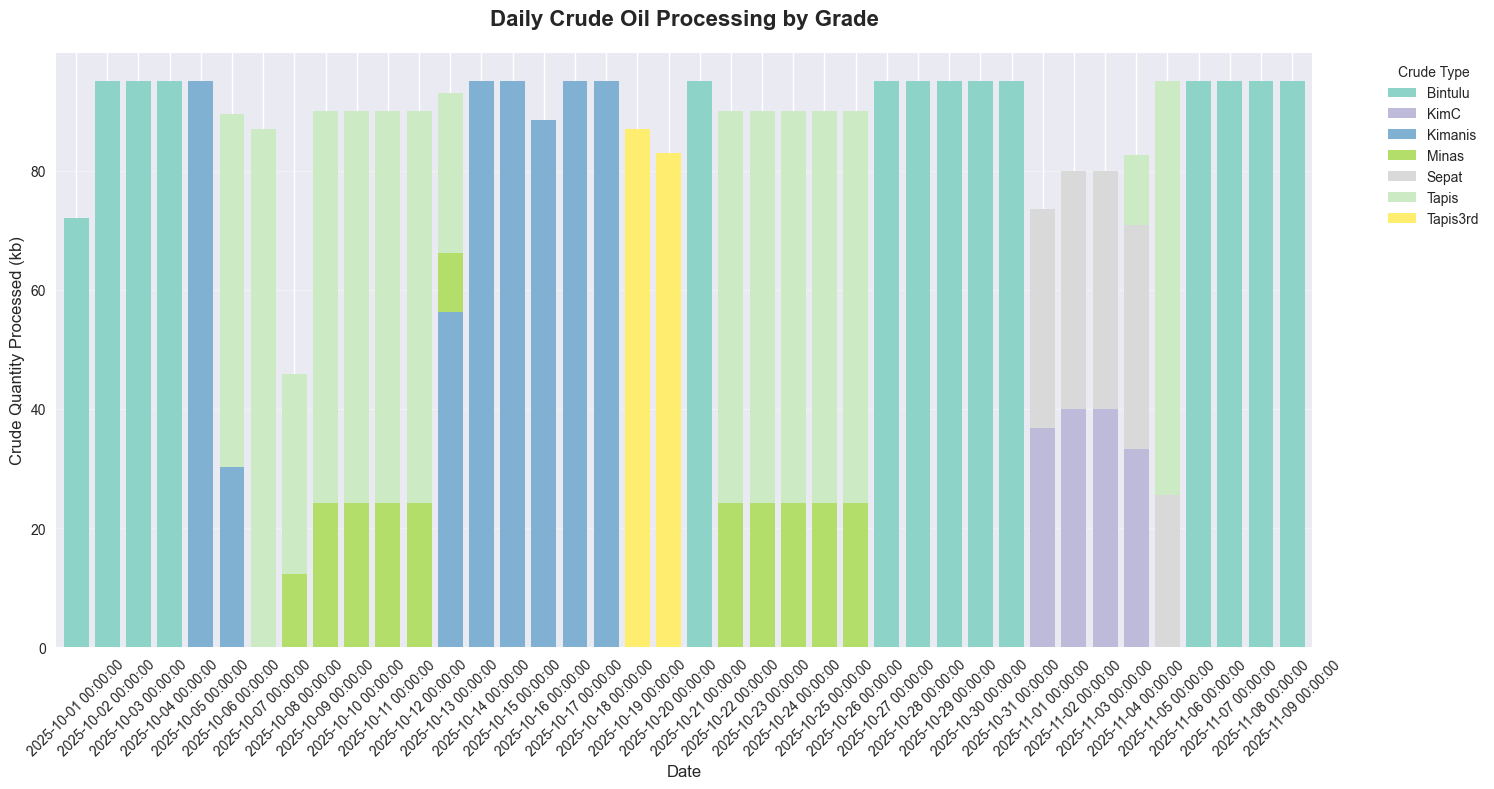

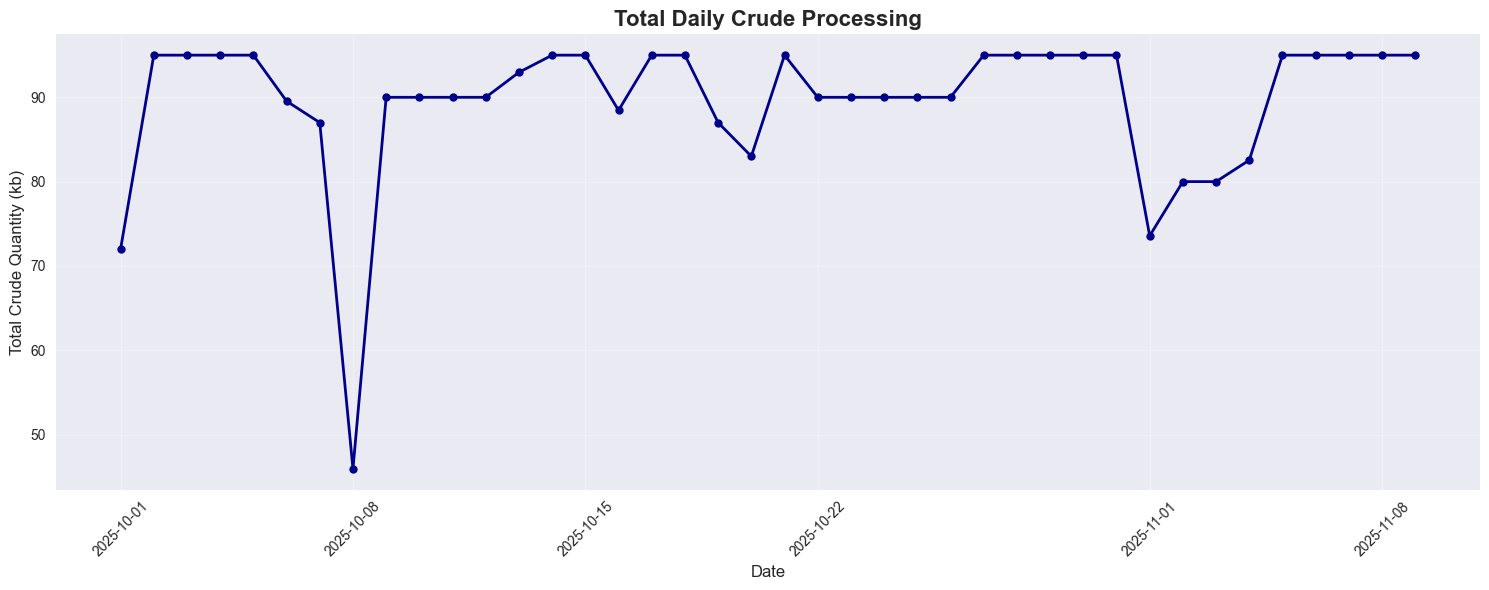

Daily Crude Processing Summary:
Total crude processed: 3577.0 kb
Average daily processing: 89.4 kb/day
Peak processing day: 95.0 kb

Crude Type Breakdown:
  Bintulu: 1307.0 kb (36.5%)
  Tapis: 879.0 kb (24.6%)
  Kimanis: 650.0 kb (18.2%)
  Minas: 241.0 kb (6.7%)
  Sepat: 180.0 kb (5.0%)
  Tapis3rd: 170.0 kb (4.8%)
  KimC: 150.0 kb (4.2%)


In [10]:
# Create Stacked Bar Chart for Daily Crude Processing
if 'df_crude_daily' in locals() and not df_crude_daily.empty:
    # Aggregate crude usage by date
    daily_crude_summary = df_crude_daily.groupby(['Date', 'Crude_Type'])['Crude_Quantity_kb'].sum().reset_index()
    
    # Pivot for stacked bar chart
    crude_pivot = daily_crude_summary.pivot(index='Date', columns='Crude_Type', values='Crude_Quantity_kb').fillna(0)
    
    # Create static stacked bar chart with matplotlib
    plt.figure(figsize=(15, 8))
    
    # Create stacked bar chart
    ax = crude_pivot.plot(kind='bar', stacked=True, figsize=(15, 8), 
                         colormap='Set3', width=0.8)
    
    # Customize the plot
    plt.title('Daily Crude Oil Processing by Grade', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Crude Quantity Processed (kb)', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Crude Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    
    # Create a secondary plot showing daily totals
    daily_totals = daily_crude_summary.groupby('Date')['Crude_Quantity_kb'].sum().reset_index()
    
    plt.figure(figsize=(15, 6))
    plt.plot(daily_totals['Date'], daily_totals['Crude_Quantity_kb'], 
             marker='o', linewidth=2, markersize=6, color='darkblue')
    plt.title('Total Daily Crude Processing', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Total Crude Quantity (kb)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("Daily Crude Processing Summary:")
    print(f"Total crude processed: {daily_crude_summary['Crude_Quantity_kb'].sum():.1f} kb")
    print(f"Average daily processing: {daily_crude_summary.groupby('Date')['Crude_Quantity_kb'].sum().mean():.1f} kb/day")
    print(f"Peak processing day: {daily_crude_summary.groupby('Date')['Crude_Quantity_kb'].sum().max():.1f} kb")
    
    # Crude type breakdown
    print("\nCrude Type Breakdown:")
    crude_breakdown = daily_crude_summary.groupby('Crude_Type')['Crude_Quantity_kb'].sum().sort_values(ascending=False)
    for crude, amount in crude_breakdown.items():
        percentage = (amount / daily_crude_summary['Crude_Quantity_kb'].sum()) * 100
        print(f"  {crude}: {amount:.1f} kb ({percentage:.1f}%)")
    
else:
    print("No crude processing data available for visualization")

## 2. Vessel Delivery Schedule Visualization

This section visualizes when crude oil deliveries arrive via different vessels.

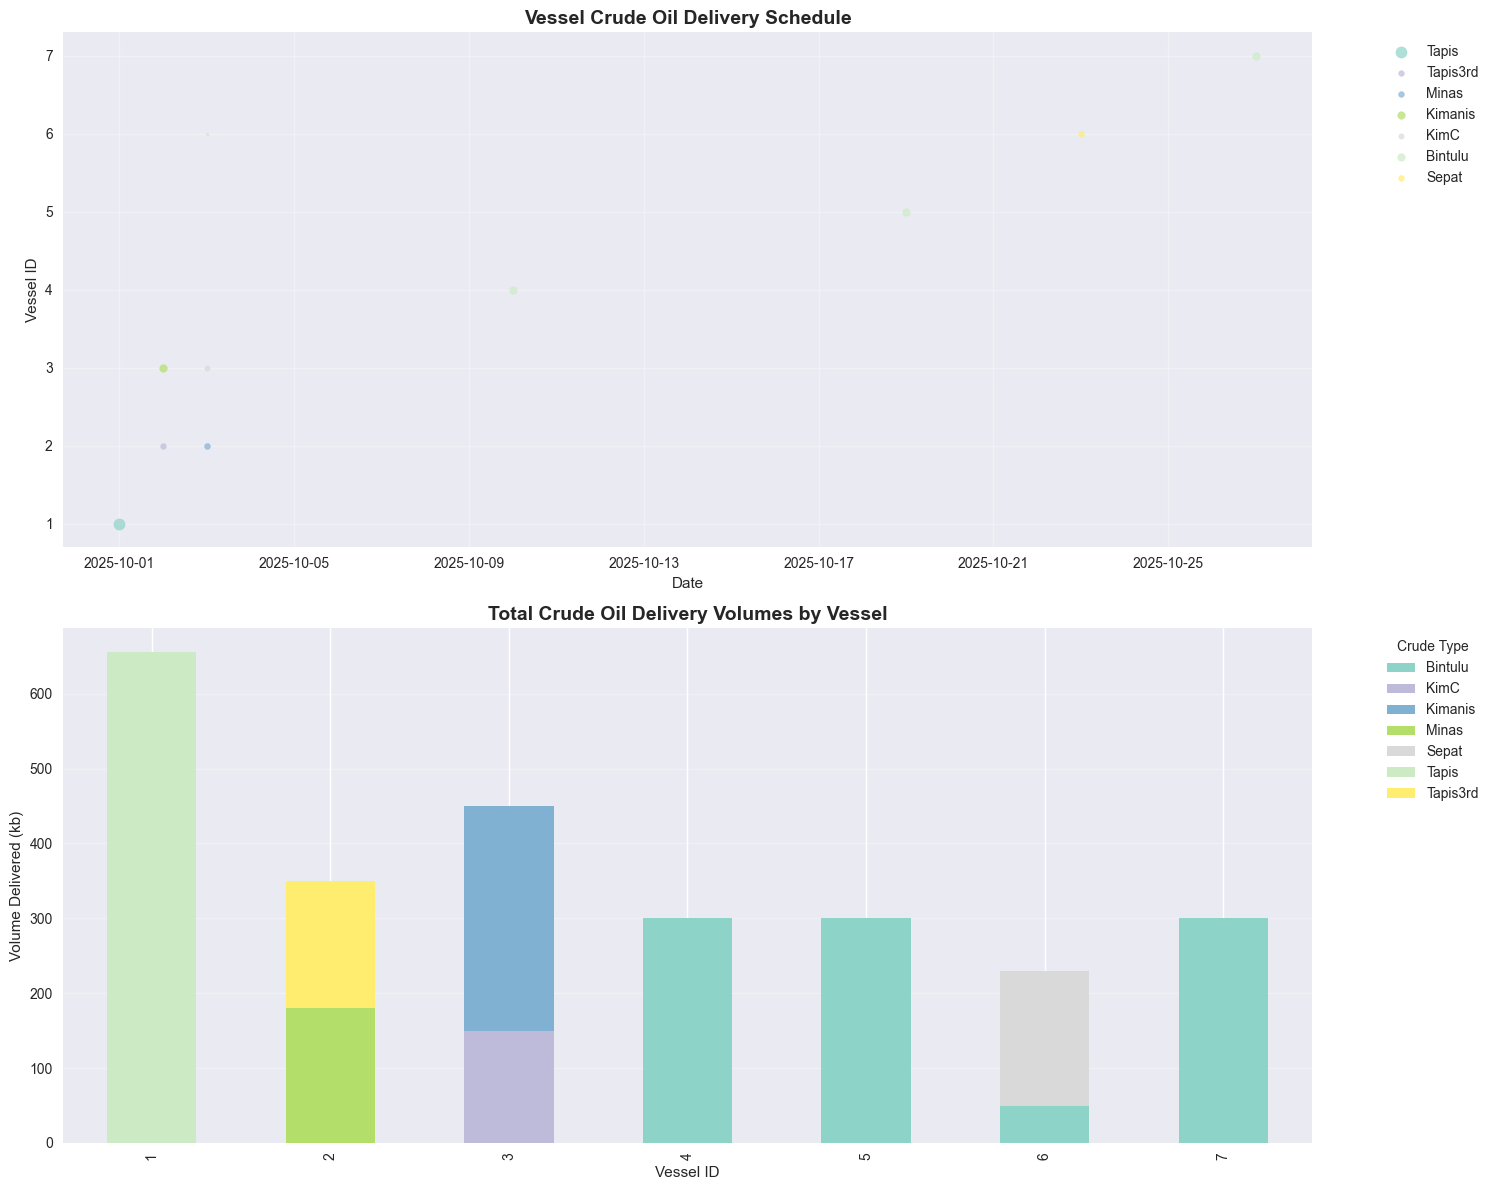

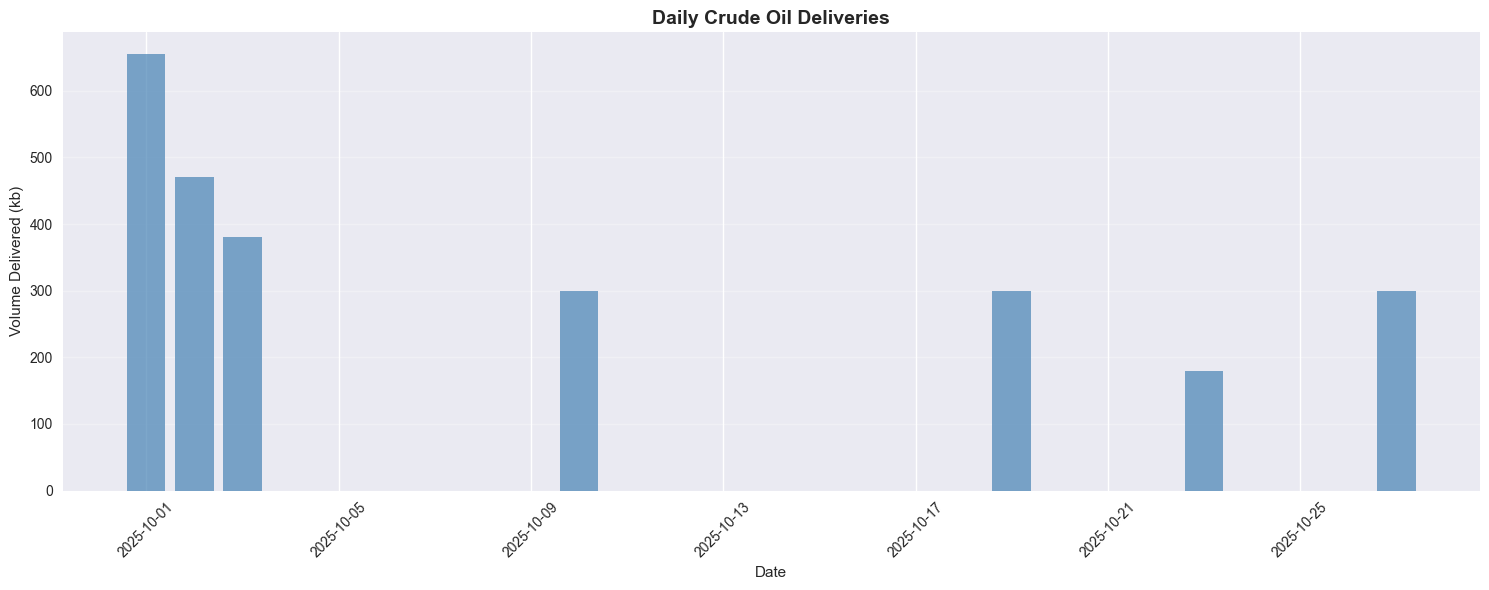

Vessel Delivery Summary:
           Total Volume (kb)  Number of Deliveries      Crude Types    Locations
Vessel ID                                                                       
1                      655.0                     1            Tapis           PM
2                      350.0                     2  Tapis3rd, Minas           PM
3                      450.0                     2    Kimanis, KimC        Sabah
4                      300.0                     1          Bintulu      Sarawak
5                      300.0                     1          Bintulu      Sarawak
6                      230.0                     2   Bintulu, Sepat  Sarawak, PM
7                      300.0                     1          Bintulu      Sarawak


In [11]:
# Create Vessel Delivery Timeline Chart
if 'df_vessel' in locals():
    # Filter loading activities to show deliveries
    df_loading = df_vessel[df_vessel['Activity'] == 'Loading'].copy()
    
    if not df_loading.empty:
        # Create timeline visualization
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
        
        # 1. Vessel delivery timeline
        vessels = df_loading['Vessel ID'].unique()
        crude_types = df_loading['Crude Type'].unique()
        colors = plt.cm.Set3(np.linspace(0, 1, len(crude_types)))
        color_map = dict(zip(crude_types, colors))
        
        y_positions = {vessel: i for i, vessel in enumerate(vessels)}
        
        for _, row in df_loading.iterrows():
            vessel = row['Vessel ID']
            date = row['Date']
            crude = row['Crude Type']
            volume = row['Volume (kb)']
            
            ax1.scatter(date, y_positions[vessel], 
                       c=[color_map[crude]], s=volume/10, alpha=0.7,
                       label=crude if crude not in [h.get_label() for h in ax1.get_children() if hasattr(h, 'get_label')] else "")
        
        ax1.set_yticks(list(y_positions.values()))
        ax1.set_yticklabels(list(y_positions.keys()))
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Vessel ID')
        ax1.set_title('Vessel Crude Oil Delivery Schedule', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # 2. Delivery volumes by vessel
        vessel_volumes = df_loading.groupby(['Vessel ID', 'Crude Type'])['Volume (kb)'].sum().unstack(fill_value=0)
        vessel_volumes.plot(kind='bar', stacked=True, ax=ax2, colormap='Set3')
        
        ax2.set_title('Total Crude Oil Delivery Volumes by Vessel', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Vessel ID')
        ax2.set_ylabel('Volume Delivered (kb)')
        ax2.legend(title='Crude Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax2.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Create daily delivery pattern
        daily_deliveries = df_loading.groupby('Date')['Volume (kb)'].sum().reset_index()
        
        plt.figure(figsize=(15, 6))
        plt.bar(daily_deliveries['Date'], daily_deliveries['Volume (kb)'], 
                color='steelblue', alpha=0.7)
        plt.title('Daily Crude Oil Deliveries', fontsize=14, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Volume Delivered (kb)')
        plt.xticks(rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Summary of deliveries
        print("Vessel Delivery Summary:")
        vessel_summary = df_loading.groupby('Vessel ID').agg({
            'Volume (kb)': ['sum', 'count'],
            'Crude Type': lambda x: ', '.join(x.unique()),
            'Location': lambda x: ', '.join(x.unique())
        }).round(1)
        vessel_summary.columns = ['Total Volume (kb)', 'Number of Deliveries', 'Crude Types', 'Locations']
        print(vessel_summary.to_string())
        
    else:
        print("No loading data found in vessel schedule")
else:
    print("Please run the data loading cell first")

## 3. Vessel Movement and Travel Tracking

This section tracks vessel movements, showing their activities over time including loading, traveling, and discharging.

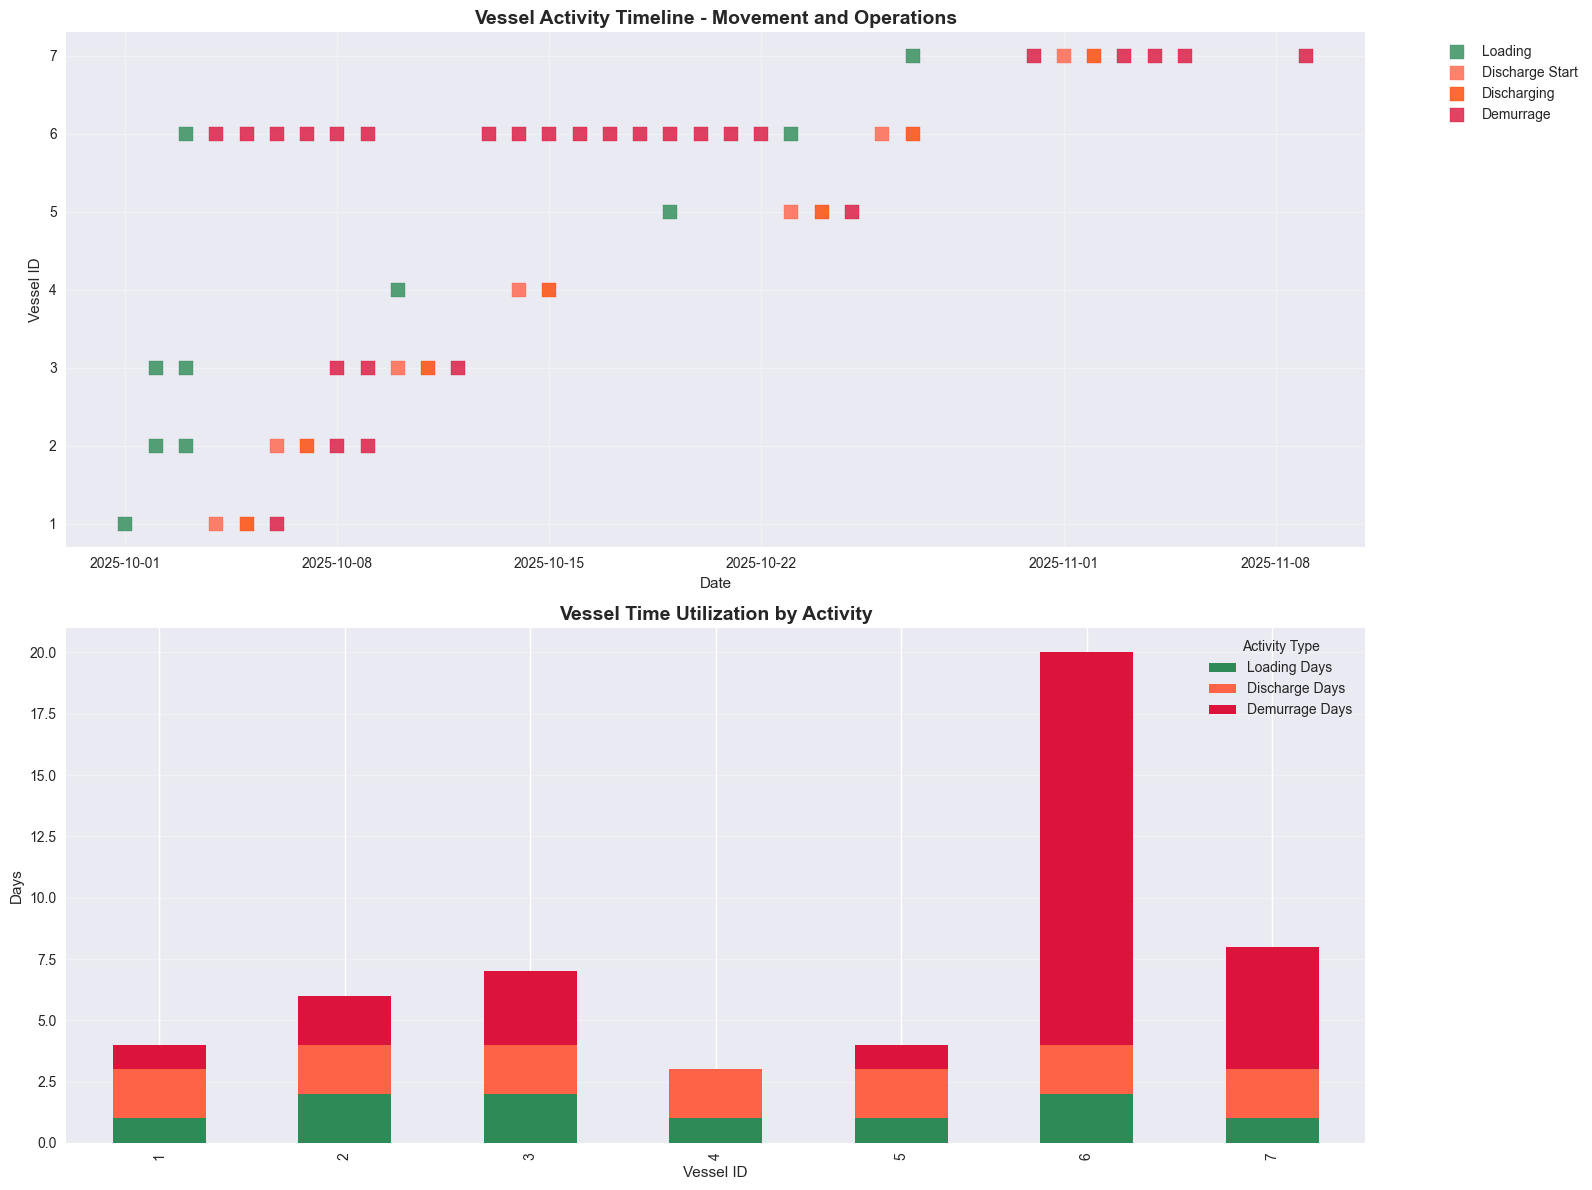

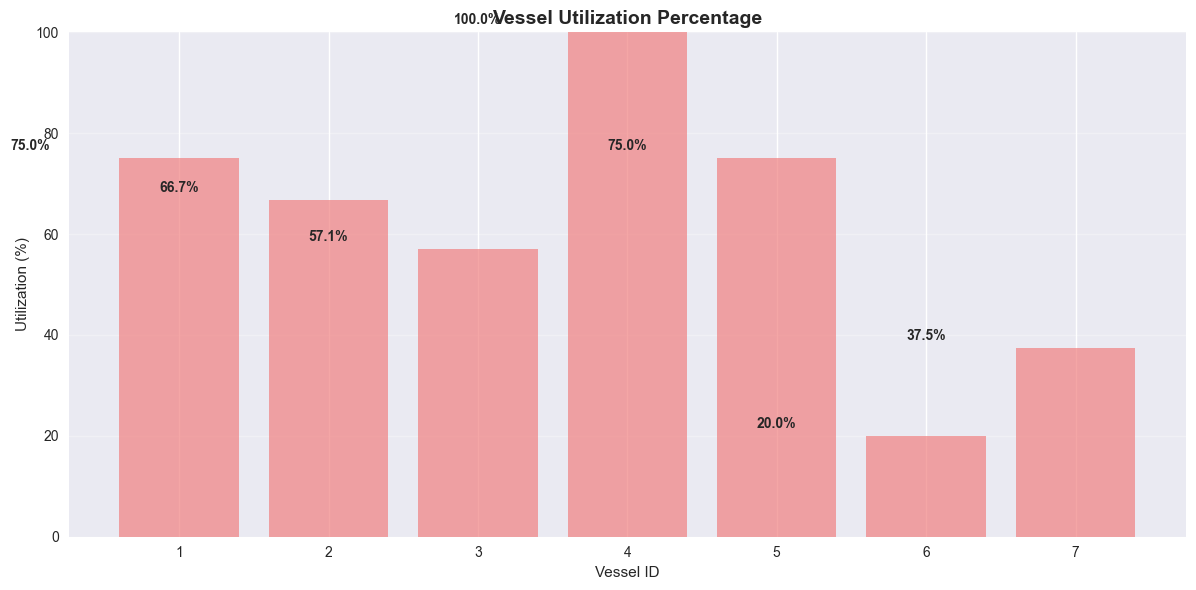

Vessel Utilization Analysis:
 Vessel ID  Loading Days  Discharge Days  Demurrage Days  Total Cargo (kb)  Utilization %
         1             1               2               1             655.0           75.0
         2             2               2               2             350.0           66.7
         3             2               2               3             450.0           57.1
         4             1               2               0             300.0          100.0
         5             1               2               1             300.0           75.0
         6             2               2              16             230.0           20.0
         7             1               2               5             300.0           37.5


In [12]:
# Create Vessel Movement Timeline
if 'df_vessel' in locals():
    # Create vessel activity timeline
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    
    # 1. Activity timeline
    vessels = df_vessel['Vessel ID'].unique()
    activities = df_vessel['Activity'].unique()
    activity_colors = {
        'Loading': '#2E8B57',      # Sea Green
        'Discharge Start': '#FF6347',  # Tomato
        'Discharging': '#FF4500',  # Orange Red
        'Demurrage': '#DC143C'     # Crimson
    }
    
    y_positions = {vessel: i for i, vessel in enumerate(vessels)}
    
    for _, row in df_vessel.iterrows():
        vessel = row['Vessel ID']
        date = row['Date']
        activity = row['Activity']
        
        color = activity_colors.get(activity, '#808080')
        ax1.scatter(date, y_positions[vessel], 
                   c=color, s=100, alpha=0.8, marker='s',
                   label=activity if activity not in [h.get_label() for h in ax1.get_children() if hasattr(h, 'get_label')] else "")
    
    ax1.set_yticks(list(y_positions.values()))
    ax1.set_yticklabels(list(y_positions.keys()))
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Vessel ID')
    ax1.set_title('Vessel Activity Timeline - Movement and Operations', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. Vessel utilization analysis
    vessel_stats = []
    for vessel_id in df_vessel['Vessel ID'].unique():
        vessel_data = df_vessel[df_vessel['Vessel ID'] == vessel_id]
        
        loading_days = len(vessel_data[vessel_data['Activity'] == 'Loading'])
        discharge_days = len(vessel_data[vessel_data['Activity'].isin(['Discharge Start', 'Discharging'])])
        demurrage_days = len(vessel_data[vessel_data['Activity'] == 'Demurrage'])
        total_days = len(vessel_data)
        
        # Calculate total cargo volume
        cargo_volume = vessel_data[vessel_data['Activity'] == 'Loading']['Volume (kb)'].sum()
        
        vessel_stats.append({
            'Vessel ID': vessel_id,
            'Loading Days': loading_days,
            'Discharge Days': discharge_days,
            'Demurrage Days': demurrage_days,
            'Total Cargo (kb)': cargo_volume,
            'Utilization %': round(((loading_days + discharge_days) / total_days) * 100, 1) if total_days > 0 else 0
        })
    
    df_vessel_stats = pd.DataFrame(vessel_stats)
    
    # Create stacked bar chart for utilization
    df_vessel_stats.set_index('Vessel ID')[['Loading Days', 'Discharge Days', 'Demurrage Days']].plot(
        kind='bar', stacked=True, ax=ax2, 
        color=['#2E8B57', '#FF6347', '#DC143C'])
    
    ax2.set_title('Vessel Time Utilization by Activity', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Vessel ID')
    ax2.set_ylabel('Days')
    ax2.legend(title='Activity Type')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create utilization percentage chart
    plt.figure(figsize=(12, 6))
    plt.bar(df_vessel_stats['Vessel ID'], df_vessel_stats['Utilization %'], 
            color='lightcoral', alpha=0.7)
    plt.title('Vessel Utilization Percentage', fontsize=14, fontweight='bold')
    plt.xlabel('Vessel ID')
    plt.ylabel('Utilization (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(df_vessel_stats['Utilization %']):
        plt.text(i, v + 1, f'{v}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("Vessel Utilization Analysis:")
    print(df_vessel_stats.to_string(index=False))
    
else:
    print("Please run the data loading cell first")

## 4. Inventory and Storage Analysis

This section shows the inventory levels and storage tank utilization over time.

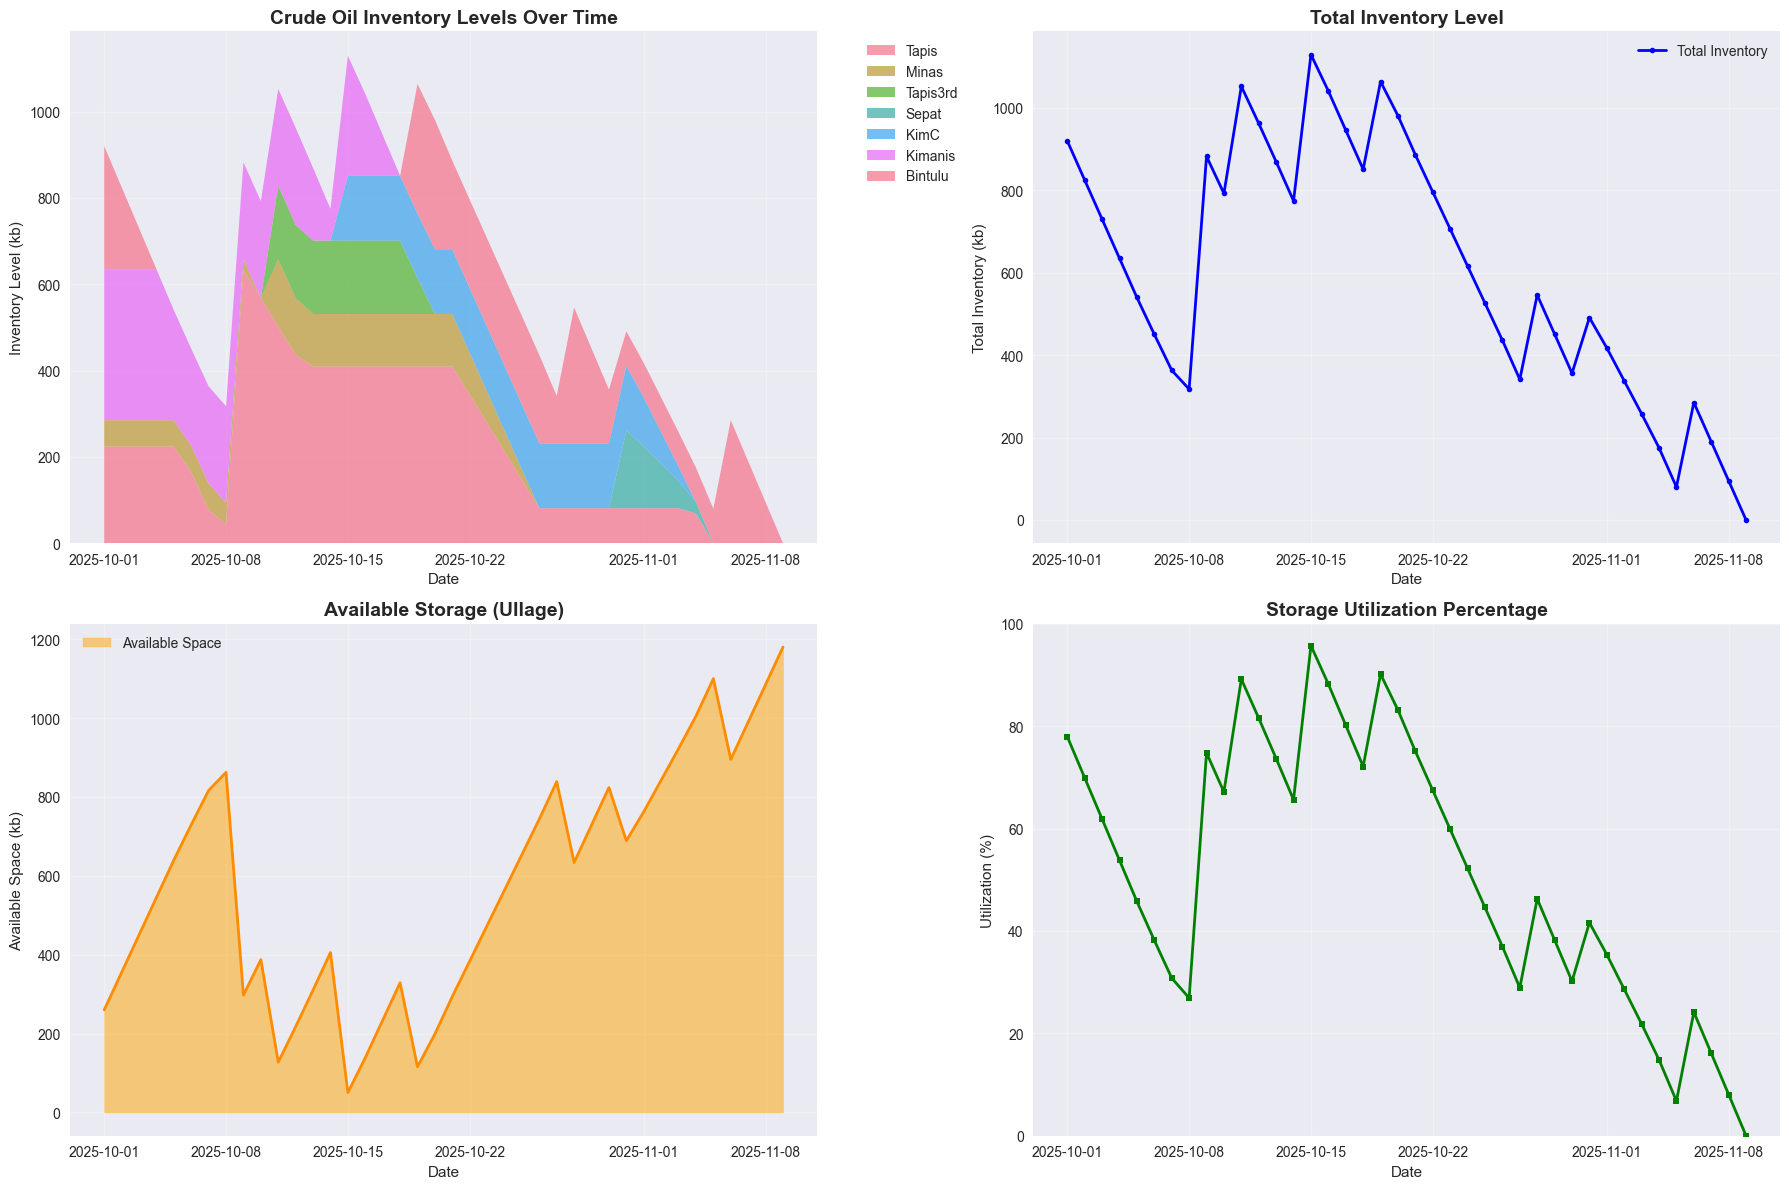

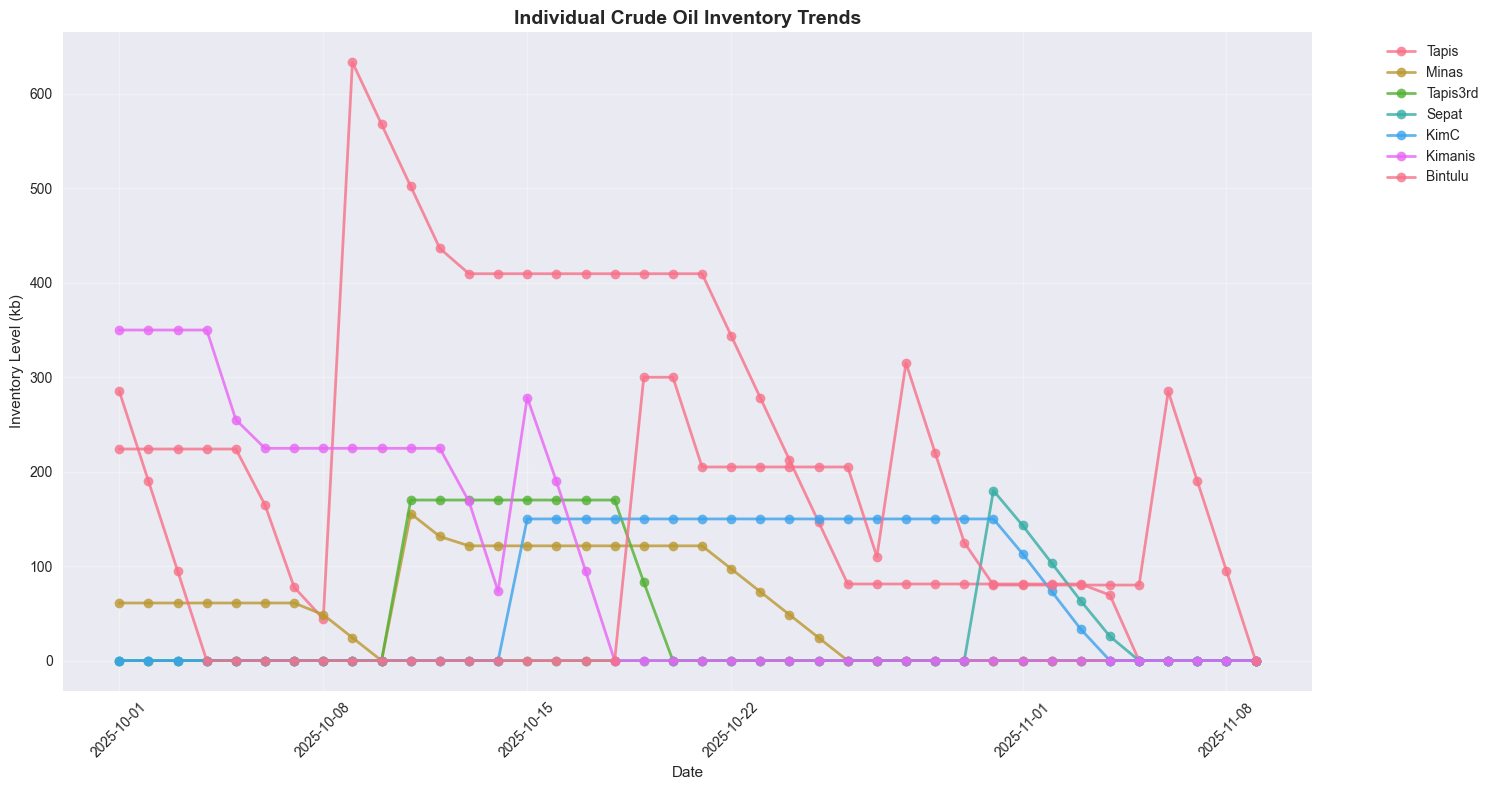

Inventory Analysis:
Maximum total inventory: 1129.6 kb
Minimum total inventory: 0.0 kb
Average total inventory: 603.0 kb
Maximum ullage: 1180.0 kb
Minimum ullage: 50.4 kb
Average storage utilization: 51.1%

Individual Crude Inventory Statistics:
  Tapis: Max=633.5kb, Min=0.0kb, Avg=225.3kb
  Minas: Max=155.7kb, Min=0.0kb, Avg=53.1kb
  Tapis3rd: Max=170.0kb, Min=0.0kb, Avg=36.1kb
  Sepat: Max=180.0kb, Min=0.0kb, Avg=12.9kb
  KimC: Max=150.0kb, Min=0.0kb, Avg=69.2kb
  Kimanis: Max=350.0kb, Min=0.0kb, Avg=100.8kb
  Bintulu: Max=315.0kb, Min=0.0kb, Avg=105.5kb


In [13]:
# Create Inventory Level Visualization
if 'df_blending' in locals():
    # Extract inventory columns
    inventory_columns = [col for col in df_blending.columns if 'Inventory' in col and col != 'Total Inventory (kb)']
    
    if inventory_columns:
        # Get unique dates and create inventory timeline
        inventory_data = df_blending.groupby('Date')[inventory_columns + ['Total Inventory (kb)', 'Ullage (kb)']].first().reset_index()
        
        # Create subplot for inventory analysis
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
        
        # 1. Stacked area chart for inventory levels
        crude_names = [col.replace('Inventory ', '').replace(' (kb)', '') for col in inventory_columns]
        inventory_values = inventory_data[inventory_columns].values.T
        
        ax1.stackplot(inventory_data['Date'], *inventory_values, 
                     labels=crude_names, alpha=0.7)
        ax1.set_title('Crude Oil Inventory Levels Over Time', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Inventory Level (kb)')
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # 2. Total inventory trend
        ax2.plot(inventory_data['Date'], inventory_data['Total Inventory (kb)'], 
                marker='o', linewidth=2, markersize=4, color='blue', label='Total Inventory')
        ax2.set_title('Total Inventory Level', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Date')
        ax2.set_ylabel('Total Inventory (kb)')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        # 3. Available storage (ullage)
        ax3.fill_between(inventory_data['Date'], inventory_data['Ullage (kb)'], 
                        alpha=0.5, color='orange', label='Available Space')
        ax3.plot(inventory_data['Date'], inventory_data['Ullage (kb)'], 
                color='darkorange', linewidth=2)
        ax3.set_title('Available Storage (Ullage)', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Date')
        ax3.set_ylabel('Available Space (kb)')
        ax3.grid(True, alpha=0.3)
        ax3.legend()
        
        # 4. Storage utilization percentage
        total_capacity = inventory_data['Total Inventory (kb)'] + inventory_data['Ullage (kb)']
        utilization = (inventory_data['Total Inventory (kb)'] / total_capacity) * 100
        
        ax4.plot(inventory_data['Date'], utilization, 
                marker='s', linewidth=2, markersize=4, color='green')
        ax4.set_title('Storage Utilization Percentage', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Date')
        ax4.set_ylabel('Utilization (%)')
        ax4.set_ylim(0, 100)
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Create individual crude inventory trends
        plt.figure(figsize=(15, 8))
        for i, col in enumerate(inventory_columns):
            crude_name = col.replace('Inventory ', '').replace(' (kb)', '')
            plt.plot(inventory_data['Date'], inventory_data[col], 
                    marker='o', linewidth=2, label=crude_name, alpha=0.8)
        
        plt.title('Individual Crude Oil Inventory Trends', fontsize=14, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Inventory Level (kb)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Inventory statistics
        print("Inventory Analysis:")
        print(f"Maximum total inventory: {inventory_data['Total Inventory (kb)'].max():.1f} kb")
        print(f"Minimum total inventory: {inventory_data['Total Inventory (kb)'].min():.1f} kb")
        print(f"Average total inventory: {inventory_data['Total Inventory (kb)'].mean():.1f} kb")
        print(f"Maximum ullage: {inventory_data['Ullage (kb)'].max():.1f} kb")
        print(f"Minimum ullage: {inventory_data['Ullage (kb)'].min():.1f} kb")
        print(f"Average storage utilization: {utilization.mean():.1f}%")
        
        # Individual crude statistics
        print("\nIndividual Crude Inventory Statistics:")
        for col in inventory_columns:
            crude_name = col.replace('Inventory ', '').replace(' (kb)', '')
            max_inv = inventory_data[col].max()
            min_inv = inventory_data[col].min()
            avg_inv = inventory_data[col].mean()
            print(f"  {crude_name}: Max={max_inv:.1f}kb, Min={min_inv:.1f}kb, Avg={avg_inv:.1f}kb")
        
    else:
        print("No inventory data found in the blending results")
else:
    print("Please run the data loading cell first")

## 5. Comprehensive Operations Dashboard

This section combines all visualizations into a comprehensive dashboard view.

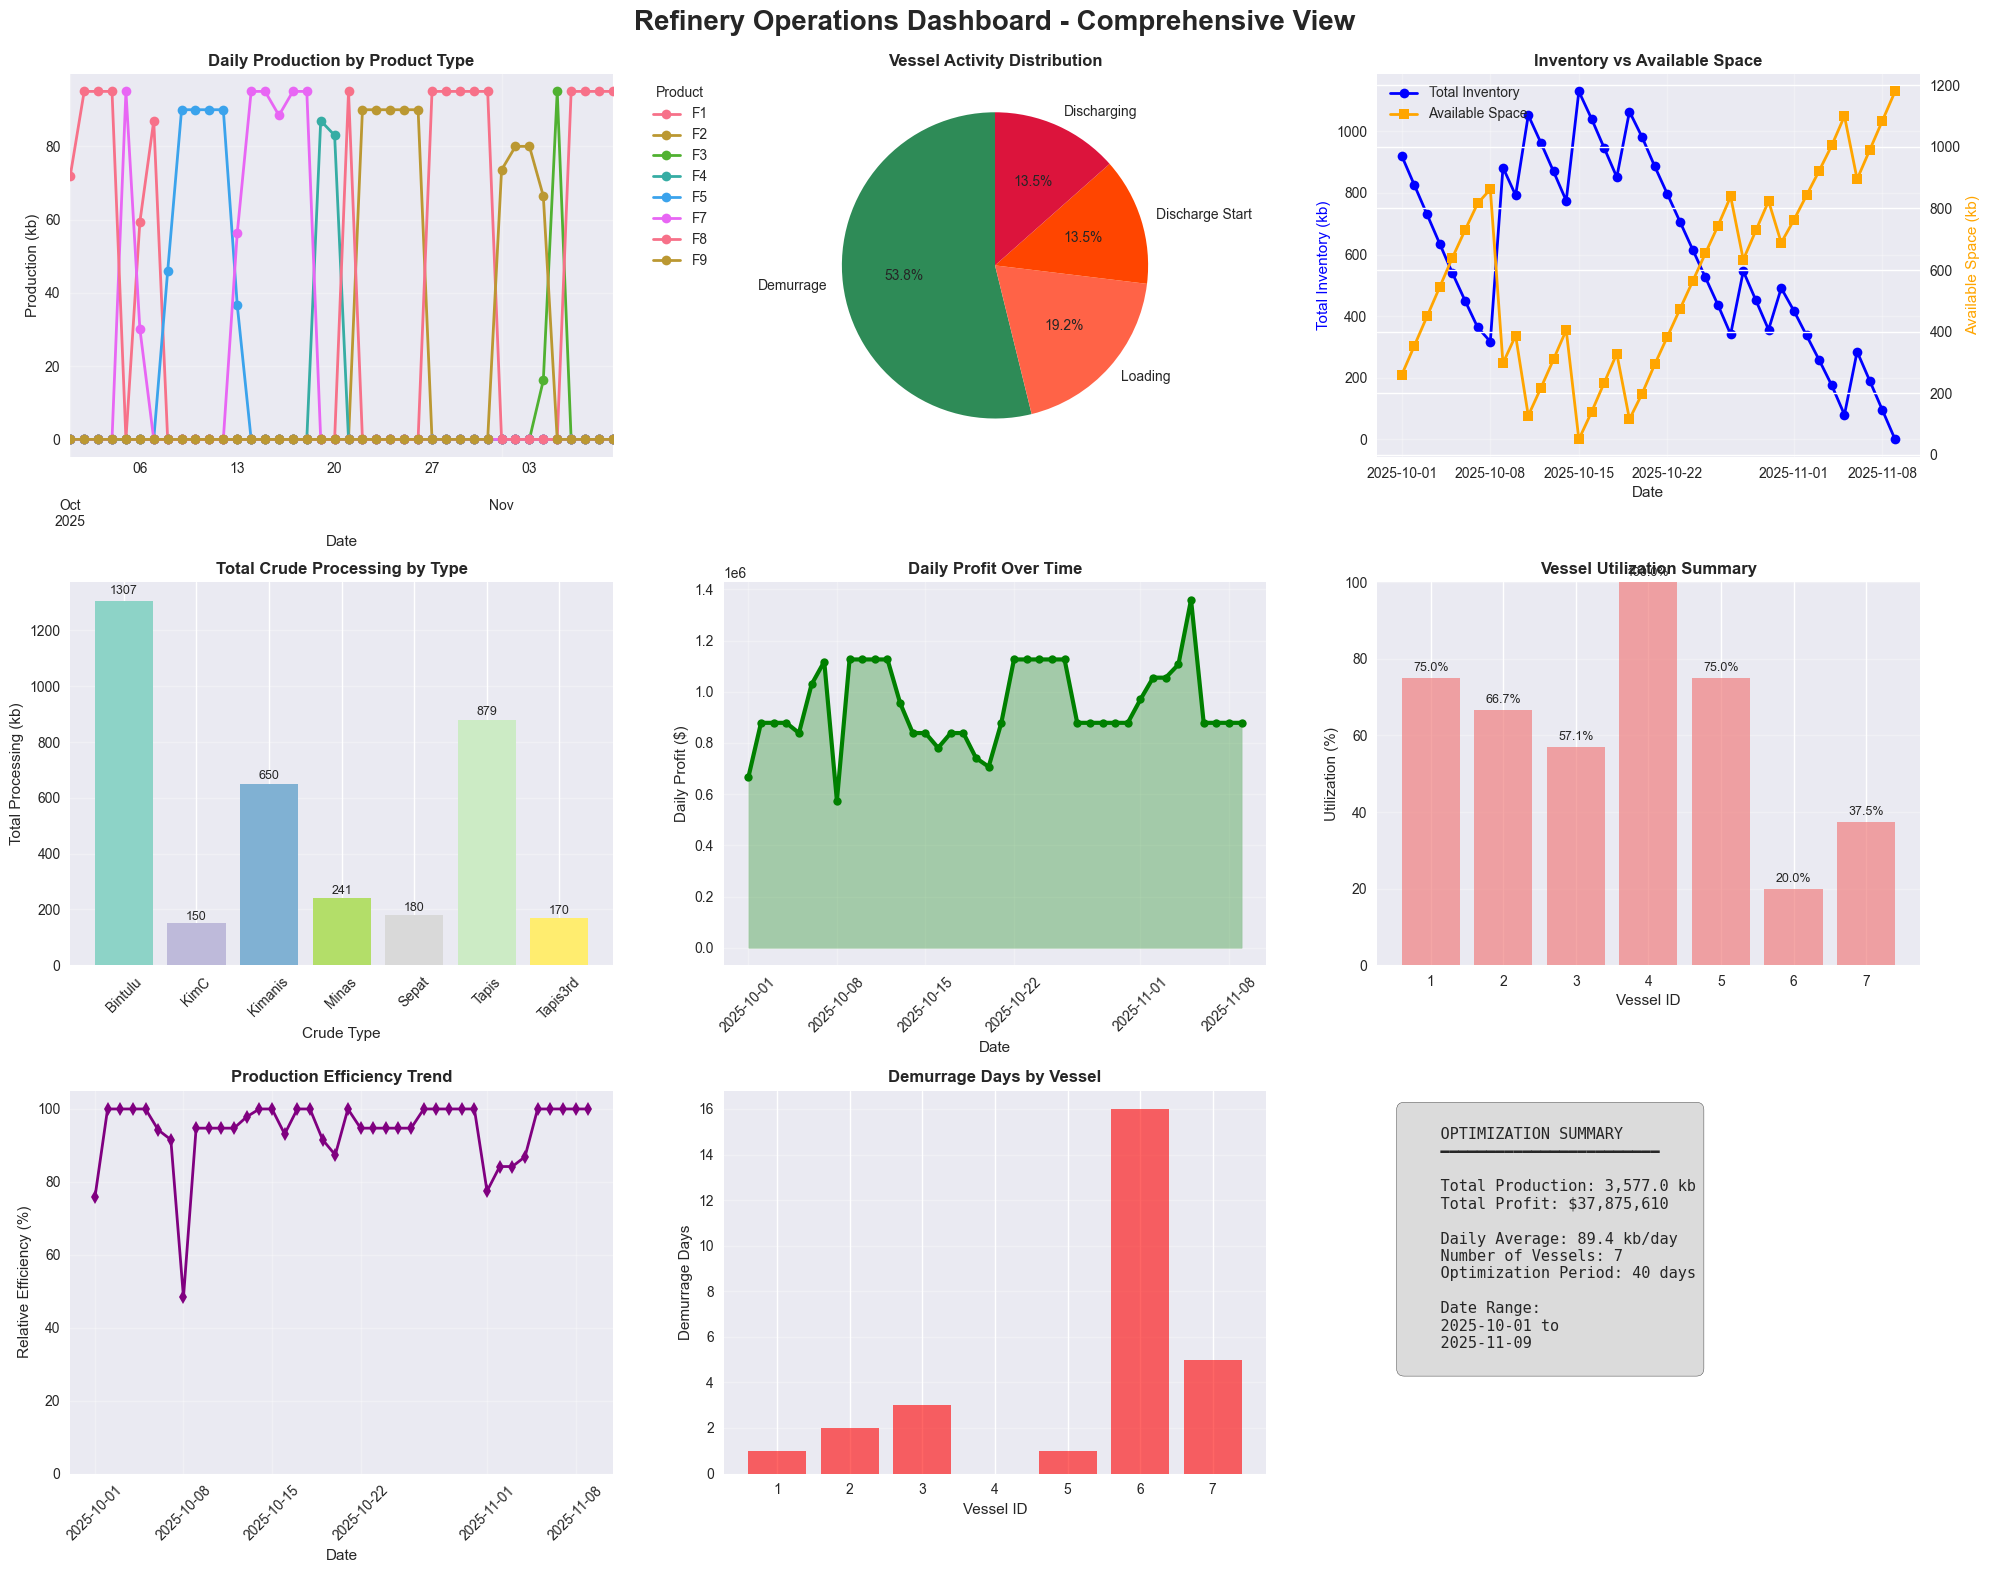

\n============================================================
REFINERY OPTIMIZATION RESULTS SUMMARY
Total Crude Processed: 3,577.0 kb
Total Production: 3,577.0 kb
Total Profit: $37,875,610.00
Average Daily Production: 89.4 kb/day
Number of Vessels Used: 7
Optimization Period: 2025-10-01 to 2025-11-09
Total Days: 40 days
\nKey Performance Insights:
- Peak production day: 95.0 kb
- Production consistency: 10.3% CV
- Total demurrage incidents: 28


In [14]:
# Create Comprehensive Operations Dashboard
if 'df_blending' in locals() and 'df_vessel' in locals():
    
    # Create comprehensive dashboard with multiple subplots
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Daily production by product (top left)
    ax1 = plt.subplot(3, 3, 1)
    daily_production = df_blending.groupby(['Date', 'Final Product'])['Quantity Produced (kb)'].sum().unstack(fill_value=0)
    daily_production.plot(kind='line', ax=ax1, marker='o', linewidth=2)
    ax1.set_title('Daily Production by Product Type', fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Production (kb)')
    ax1.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # 2. Vessel activity distribution (top center)
    ax2 = plt.subplot(3, 3, 2)
    vessel_activity = df_vessel['Activity'].value_counts()
    colors = ['#2E8B57', '#FF6347', '#FF4500', '#DC143C']
    ax2.pie(vessel_activity.values, labels=vessel_activity.index, autopct='%1.1f%%', 
            colors=colors[:len(vessel_activity)], startangle=90)
    ax2.set_title('Vessel Activity Distribution', fontweight='bold')
    
    # 3. Total inventory vs available space (top right)
    ax3 = plt.subplot(3, 3, 3)
    inventory_timeline = df_blending.groupby('Date')[['Total Inventory (kb)', 'Ullage (kb)']].first().reset_index()
    ax3_twin = ax3.twinx()
    
    line1 = ax3.plot(inventory_timeline['Date'], inventory_timeline['Total Inventory (kb)'], 
                     color='blue', linewidth=2, marker='o', label='Total Inventory')
    line2 = ax3_twin.plot(inventory_timeline['Date'], inventory_timeline['Ullage (kb)'], 
                          color='orange', linewidth=2, marker='s', label='Available Space')
    
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Total Inventory (kb)', color='blue')
    ax3_twin.set_ylabel('Available Space (kb)', color='orange')
    ax3.set_title('Inventory vs Available Space', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Combine legends
    lines1, labels1 = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3_twin.get_legend_handles_labels()
    ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    # 4. Crude processing by type (middle left)
    ax4 = plt.subplot(3, 3, 4)
    if 'daily_crude_summary' in locals():
        crude_totals = daily_crude_summary.groupby('Crude_Type')['Crude_Quantity_kb'].sum().reset_index()
        bars = ax4.bar(crude_totals['Crude_Type'], crude_totals['Crude_Quantity_kb'], 
                       color=plt.cm.Set3(np.linspace(0, 1, len(crude_totals))))
        ax4.set_title('Total Crude Processing by Type', fontweight='bold')
        ax4.set_xlabel('Crude Type')
        ax4.set_ylabel('Total Processing (kb)')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                    f'{height:.0f}', ha='center', va='bottom', fontsize=9)
    
    # 5. Production profit over time (middle center)
    ax5 = plt.subplot(3, 3, 5)
    daily_profit = df_blending.groupby('Date')['Profit'].sum().reset_index()
    ax5.plot(daily_profit['Date'], daily_profit['Profit'], 
             color='green', linewidth=3, marker='o', markersize=6)
    ax5.fill_between(daily_profit['Date'], daily_profit['Profit'], alpha=0.3, color='green')
    ax5.set_title('Daily Profit Over Time', fontweight='bold')
    ax5.set_xlabel('Date')
    ax5.set_ylabel('Daily Profit ($)')
    ax5.grid(True, alpha=0.3)
    ax5.tick_params(axis='x', rotation=45)
    
    # 6. Vessel utilization summary (middle right)
    ax6 = plt.subplot(3, 3, 6)
    if 'df_vessel_stats' in locals():
        vessel_util = df_vessel_stats.set_index('Vessel ID')['Utilization %']
        bars = ax6.bar(vessel_util.index, vessel_util.values, color='lightcoral', alpha=0.7)
        ax6.set_title('Vessel Utilization Summary', fontweight='bold')
        ax6.set_xlabel('Vessel ID')
        ax6.set_ylabel('Utilization (%)')
        ax6.set_ylim(0, 100)
        ax6.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax6.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # 7. Production efficiency trend (bottom left)
    ax7 = plt.subplot(3, 3, 7)
    daily_totals = df_blending.groupby('Date')['Quantity Produced (kb)'].sum().reset_index()
    efficiency = daily_totals['Quantity Produced (kb)'] / daily_totals['Quantity Produced (kb)'].max() * 100
    ax7.plot(daily_totals['Date'], efficiency, color='purple', linewidth=2, marker='d')
    ax7.set_title('Production Efficiency Trend', fontweight='bold')
    ax7.set_xlabel('Date')
    ax7.set_ylabel('Relative Efficiency (%)')
    ax7.set_ylim(0, 105)
    ax7.grid(True, alpha=0.3)
    ax7.tick_params(axis='x', rotation=45)
    
    # 8. Demurrage analysis (bottom center)
    ax8 = plt.subplot(3, 3, 8)
    demurrage_data = df_vessel[df_vessel['Activity'] == 'Demurrage']
    if not demurrage_data.empty:
        demurrage_by_vessel = demurrage_data.groupby('Vessel ID').size()
        ax8.bar(demurrage_by_vessel.index, demurrage_by_vessel.values, 
                color='red', alpha=0.6)
        ax8.set_title('Demurrage Days by Vessel', fontweight='bold')
        ax8.set_xlabel('Vessel ID')
        ax8.set_ylabel('Demurrage Days')
        ax8.grid(axis='y', alpha=0.3)
    else:
        ax8.text(0.5, 0.5, 'No Demurrage\nRecorded', ha='center', va='center',
                transform=ax8.transAxes, fontsize=12, fontweight='bold')
        ax8.set_title('Demurrage Analysis', fontweight='bold')
    
    # 9. Overall summary metrics (bottom right)
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')
    
    # Calculate key metrics
    total_production = df_blending['Quantity Produced (kb)'].sum()
    total_profit = df_blending['Profit'].sum()
    avg_daily_production = total_production / len(df_blending['Date'].unique())
    num_vessels = df_vessel['Vessel ID'].nunique()
    total_days = len(df_blending['Date'].unique())
    
    # Create summary text
    summary_text = f"""
    OPTIMIZATION SUMMARY
    ━━━━━━━━━━━━━━━━━━━━━━━━
    
    Total Production: {total_production:,.1f} kb
    Total Profit: ${total_profit:,.0f}
    
    Daily Average: {avg_daily_production:,.1f} kb/day
    Number of Vessels: {num_vessels}
    Optimization Period: {total_days} days
    
    Date Range:
    {df_blending['Date'].min().date()} to
    {df_blending['Date'].max().date()}
    """
    
    ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes, 
            fontsize=11, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
    
    # Adjust layout and show
    plt.suptitle('Refinery Operations Dashboard - Comprehensive View', 
                fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)
    plt.show()
    
    # Final summary statistics
    print("\\n" + "="*60)
    print("REFINERY OPTIMIZATION RESULTS SUMMARY")
    print("="*60)
    
    if 'df_crude_daily' in locals():
        total_crude = df_crude_daily['Crude_Quantity_kb'].sum()
        print(f"Total Crude Processed: {total_crude:,.1f} kb")
    
    print(f"Total Production: {total_production:,.1f} kb")
    print(f"Total Profit: ${total_profit:,.2f}")
    print(f"Average Daily Production: {avg_daily_production:,.1f} kb/day")
    print(f"Number of Vessels Used: {num_vessels}")
    print(f"Optimization Period: {df_blending['Date'].min().date()} to {df_blending['Date'].max().date()}")
    print(f"Total Days: {total_days} days")
    
    # Additional insights
    print("\\nKey Performance Insights:")
    print(f"- Peak production day: {daily_totals['Quantity Produced (kb)'].max():.1f} kb")
    print(f"- Production consistency: {(daily_totals['Quantity Produced (kb)'].std()/daily_totals['Quantity Produced (kb)'].mean()*100):.1f}% CV")
    if 'demurrage_data' in locals() and not demurrage_data.empty:
        print(f"- Total demurrage incidents: {len(demurrage_data)}")
    else:
        print("- No demurrage incidents recorded")
    
else:
    print("Please run all previous cells to generate the dashboard")